# 0x10 Graphical and Sequential Models

> ✨ **This notebook is co-authored with OpenAI Codex**

In this notebook, we will work with two kinds probabilistic models:
- **Bayesian networks**, a _graphical_ model for structured dependencies among variables. A Bayesian network asks **which variables are directly related after we account for their parents in the graph**.
- **Markov chains**, a _sequential_ model for transitions over time. A Markov chain asks **how a system moves from one state to the next**.

In [1]:
# Setting up environment
import itertools

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")


## 1. Bayesian Networks

We start with a tiny causal world of a small lawn where we have three binary variables:
- `Rain`: whether it is raining
- `Sprinkler`: whether the lawn sprinkler turns on
- `WetGrass`: whether the grass is wet

### 1.1 A tiny causal world

Suppose rain makes wet grass more likely.
A sprinkler also makes wet grass more likely.
But if it is already raining, the sprinkler is a bit less likely to be turned on.

That story gives us this directed graph:


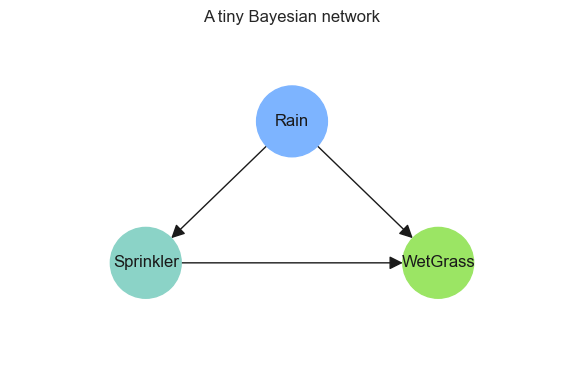

In [2]:
G_bn = nx.DiGraph()
G_bn.add_edges_from(
    [
        ("Rain", "Sprinkler"),
        ("Rain", "WetGrass"),
        ("Sprinkler", "WetGrass"),
    ]
)

pos = {
    "Rain": (0.0, 0.7),
    "Sprinkler": (-0.7, 0.0),
    "WetGrass": (0.7, 0.0),
}

plt.figure(figsize=(6, 4))
nx.draw_networkx(
    G_bn,
    pos=pos,
    node_color=["#7db4ff", "#8bd3c7", "#9be564"],
    node_size=2600,
    arrowsize=20,
    font_size=12,
)
plt.title("A tiny Bayesian network")
plt.xlim(-1.35, 1.35)
plt.ylim(-0.55, 1.15)
plt.axis("off")
plt.tight_layout()
plt.show()


In this toy story, we give the arrows a causal interpretation:
- `Rain` directly affects `Sprinkler`
- `Rain` directly affects `WetGrass`
- `Sprinkler` directly affects `WetGrass`

More generally, a Bayesian-network arrow represents a direct conditional-dependence assumption in the model. It is not automatically a causal claim unless the model is built and justified that way.

A useful interpretation is that once we know `Rain` and `Sprinkler`, we do not need any extra variables to describe `WetGrass` in this toy world.


### 1.2 Writing the joint distribution from the graph

The graph turns one big joint distribution into smaller local pieces:

$$
P(R, S, W) = P(R) P(S \mid R) P(W \mid R, S)
$$

This factorization is the main payoff of Bayesian networks.
Instead of manually storing one giant probability table, we store a few local conditional probability tables (CPTs).


In [3]:
p_rain = {True: 0.2, False: 0.8}

p_sprinkler_given_rain = {
    True: {True: 0.1, False: 0.9},
    False: {True: 0.4, False: 0.6},
}

p_wet_given_rain_sprinkler = {
    (True, True): {True: 0.99, False: 0.01},
    (True, False): {True: 0.90, False: 0.10},
    (False, True): {True: 0.80, False: 0.20},
    (False, False): {True: 0.05, False: 0.95},
}

print("P(Rain=True) =", p_rain[True])
print("P(Sprinkler=True | Rain=False) =", p_sprinkler_given_rain[False][True])
print("P(WetGrass=True | Rain=True, Sprinkler=False) =", p_wet_given_rain_sprinkler[(True, False)][True])


P(Rain=True) = 0.2
P(Sprinkler=True | Rain=False) = 0.4
P(WetGrass=True | Rain=True, Sprinkler=False) = 0.9


In [4]:
def joint_prob_bn(rain, sprinkler, wet_grass):
    return (
        p_rain[rain]
        * p_sprinkler_given_rain[rain][sprinkler]
        * p_wet_given_rain_sprinkler[(rain, sprinkler)][wet_grass]
    )


joint_rows = []
for rain, sprinkler, wet_grass in itertools.product([False, True], repeat=3):
    joint_rows.append(
        {
            "Rain": rain,
            "Sprinkler": sprinkler,
            "WetGrass": wet_grass,
            "Probability": joint_prob_bn(rain, sprinkler, wet_grass),
        }
    )

joint_df = pd.DataFrame(joint_rows).sort_values(
    ["Rain", "Sprinkler", "WetGrass"], ignore_index=True
)
joint_df


,Rain,Sprinkler,WetGrass,Probability
0,False,False,False,0.4560
1,False,False,True,0.0240
2,False,True,False,0.0640
3,False,True,True,0.2560
4,True,False,False,0.0180
5,True,False,True,0.1620
6,True,True,False,0.0002
7,True,True,True,0.0198


In [5]:
prob_sum = joint_df["Probability"].sum()
print(f"Sum of all joint probabilities: {prob_sum:.6f}")
assert np.isclose(prob_sum, 1.0)


Sum of all joint probabilities: 1.000000


> 🤔 **THINKING**
>
> - Why is it useful that we can compute the full joint table from local pieces?


### 1.3 Exact inference by enumeration

Now let us answer questions such as:
- What is the probability that the grass is wet?
- If we observe wet grass, how much more likely does rain become?

For a tiny network like this, brute-force enumeration is perfect.
We simply sum the probabilities of all hidden configurations consistent with our evidence.

In symbols:

$$
P(X \mid E) = \frac{P(X, E)}{P(E)}
$$

and each of those terms can be computed by summing over the unobserved variables.


In [6]:
VARIABLES = ["Rain", "Sprinkler", "WetGrass"]


def assignment_prob(assignment):
    return joint_prob_bn(
        assignment["Rain"],
        assignment["Sprinkler"],
        assignment["WetGrass"],
    )


def query_bn(query_var, query_value=True, evidence=None):
    evidence = evidence or {}
    numerator = 0.0
    denominator = 0.0

    for values in itertools.product([False, True], repeat=len(VARIABLES)):
        assignment = dict(zip(VARIABLES, values, strict=False))

        if any(assignment[var] != val for var, val in evidence.items()):
            continue

        prob = assignment_prob(assignment)
        denominator += prob
        if assignment[query_var] == query_value:
            numerator += prob

    if np.isclose(denominator, 0.0):
        raise ValueError("Evidence has zero probability under this model.")

    return numerator / denominator


In [7]:
queries = pd.Series(
    {
        "P(WetGrass=True)": query_bn("WetGrass"),
        "P(Rain=True | WetGrass=True)": query_bn("Rain", evidence={"WetGrass": True}),
        "P(Sprinkler=True | WetGrass=True)": query_bn("Sprinkler", evidence={"WetGrass": True}),
        "P(Rain=True | WetGrass=True, Sprinkler=False)": query_bn(
            "Rain", evidence={"WetGrass": True, "Sprinkler": False}
        ),
    }
)
queries.round(4)


P(WetGrass=True)                                 0.4618
P(Rain=True | WetGrass=True)                     0.3937
P(Sprinkler=True | WetGrass=True)                0.5972
P(Rain=True | WetGrass=True, Sprinkler=False)    0.8710
dtype: float64

Notice the pattern:
- before seeing anything, rain has prior probability `0.2`
- after observing wet grass, rain becomes much more plausible
- if we also observe that the sprinkler was **off**, rain becomes even more plausible

This is exactly the kind of probabilistic reasoning Bayesian networks are designed for.


### 1.4 What changes when we observe evidence?

A nice way to see posterior updates is to compare the prior and posterior side by side.


In [8]:
comparison_df = pd.DataFrame(
    {
        "Scenario": [
            "Prior",
            "Given WetGrass=True",
            "Given WetGrass=True and Sprinkler=False",
        ],
        "P(Rain=True)": [
            query_bn("Rain"),
            query_bn("Rain", evidence={"WetGrass": True}),
            query_bn("Rain", evidence={"WetGrass": True, "Sprinkler": False}),
        ],
    }
)
comparison_df


,Scenario,P(Rain=True)
0,Prior,0.200000
1,Given WetGrass=True,0.393677
2,Given WetGrass=True and Sprinkler=False,0.870968


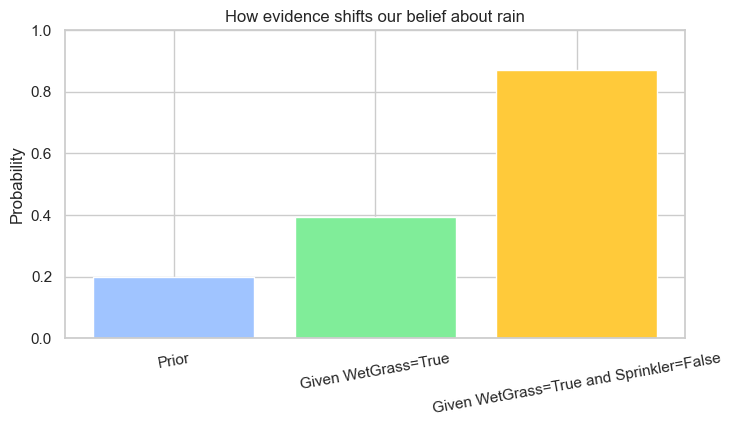

In [9]:
plt.figure(figsize=(8, 4))
plt.bar(comparison_df["Scenario"], comparison_df["P(Rain=True)"], color=["#a0c4ff", "#80ed99", "#ffca3a"])
plt.ylim(0, 1)
plt.ylabel("Probability")
plt.title("How evidence shifts our belief about rain")
plt.xticks(rotation=10)
plt.show()


The model is redistributing probability mass across all hidden cases that remain compatible with the evidence.

For example, `WetGrass=True` can happen because of rain, because of the sprinkler, or because of both.
If we additionally learn `Sprinkler=False`, many sprinkler-based explanations disappear, so rain gets more probability.


> 📚 **EXERCISE**
>
> - Try changing one CPT row and re-running the Bayesian-network section. Remember to update the complementary probability so the row still sums to 1.
> - Increase `P(Sprinkler=True | Rain=False)` from `0.4` to `0.7`, and decrease `P(Sprinkler=False | Rain=False)` from `0.6` to `0.3`. How much does `P(Rain=True | WetGrass=True)` move?
> - Decrease `P(WetGrass=True | Rain=False, Sprinkler=False)` from `0.05` to `0.01`, and increase `P(WetGrass=False | Rain=False, Sprinkler=False)` from `0.95` to `0.99`. Which posterior changes more?


That finishes our Bayesian-network example.
The important lesson is not the specific rain story, but the workflow:
- encode assumptions with a graph
- attach local probability tables
- answer new questions when evidence arrives


## 2. Markov Chains

Now let us switch from **structured dependencies** to **sequential dynamics**.

A Markov chain models a system that moves between a finite set of states.
The Markov assumption says that the next state depends only on the current state, not on the full past.


### 2.1 A simple example: weather moods over days

We will use three weather states:
- `Sunny`
- `Cloudy`
- `Rainy`

A transition matrix stores the probability of moving from today's weather to tomorrow's weather.


In [10]:
states = ["Sunny", "Cloudy", "Rainy"]
state_to_idx = {state: i for i, state in enumerate(states)}

P = np.array(
    [
        [0.70, 0.20, 0.10],
        [0.30, 0.40, 0.30],
        [0.20, 0.30, 0.50],
    ]
)

transition_df = pd.DataFrame(P, index=states, columns=states)
transition_df


,Sunny,Cloudy,Rainy
Sunny,0.7,0.2,0.1
Cloudy,0.3,0.4,0.3
Rainy,0.2,0.3,0.5


If the current state is `Sunny`, the first row tells us:
- 70% chance that tomorrow is still `Sunny`
- 20% chance that it becomes `Cloudy`
- 10% chance that it becomes `Rainy`

Every row must sum to 1 because one of the next states must happen.


Row sums: [1. 1. 1.]


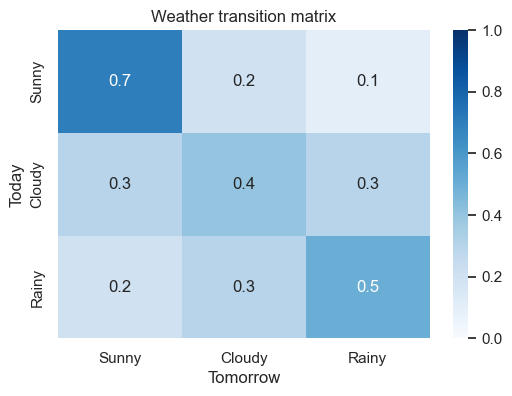

In [11]:
row_sums = P.sum(axis=1)
print("Row sums:", row_sums)
assert np.allclose(row_sums, 1.0)

plt.figure(figsize=(6, 4))
sns.heatmap(transition_df, annot=True, cmap="Blues", vmin=0, vmax=1)
plt.title("Weather transition matrix")
plt.ylabel("Today")
plt.xlabel("Tomorrow")
plt.show()


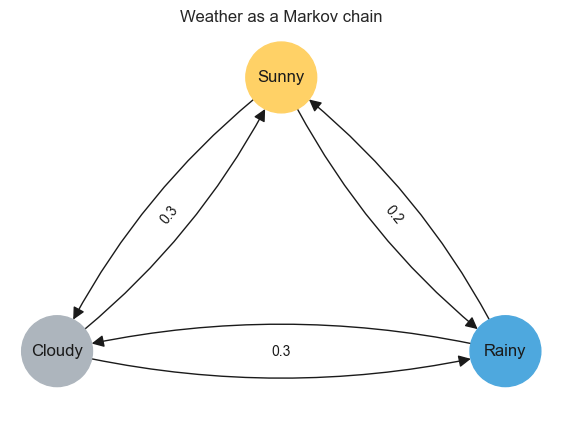

In [12]:
G_mc = nx.DiGraph()
for i, src in enumerate(states):
    for j, dst in enumerate(states):
        if P[i, j] > 0:
            G_mc.add_edge(src, dst, weight=P[i, j])

pos_mc = {
    "Sunny": (0.0, 1.0),
    "Cloudy": (-1.0, 0.0),
    "Rainy": (1.0, 0.0),
}
edge_labels = {(u, v): f"{d['weight']:.1f}" for u, v, d in G_mc.edges(data=True)}

plt.figure(figsize=(7, 5))
nx.draw_networkx(
    G_mc,
    pos=pos_mc,
    node_color=["#ffd166", "#adb5bd", "#4ea8de"],
    node_size=2600,
    arrowsize=18,
    connectionstyle="arc3,rad=0.12",
    font_size=12,
)
nx.draw_networkx_edge_labels(G_mc, pos_mc, edge_labels=edge_labels, font_size=10)
plt.title("Weather as a Markov chain")
plt.axis("off")
plt.show()


### 2.2 Simulating trajectories

Once we have the transition matrix, we can generate possible futures.
A trajectory is just a sequence of visited states.


In [13]:
def simulate_markov_chain(P, states, start_state, n_steps, rng=None):
    rng = np.random.default_rng(rng)
    current = states.index(start_state)
    trajectory = [states[current]]

    for _ in range(n_steps):
        current = rng.choice(len(states), p=P[current])
        trajectory.append(states[current])

    return trajectory


trajectory = simulate_markov_chain(P, states, start_state="Sunny", n_steps=25, rng=42)
trajectory


['Sunny',
 'Cloudy',
 'Cloudy',
 'Rainy',
 'Rainy',
 'Sunny',
 'Rainy',
 'Rainy',
 'Rainy',
 'Sunny',
 'Sunny',
 'Sunny',
 'Rainy',
 'Rainy',
 'Rainy',
 'Cloudy',
 'Sunny',
 'Sunny',
 'Sunny',
 'Cloudy',
 'Cloudy',
 'Rainy',
 'Cloudy',
 'Rainy',
 'Rainy',
 'Rainy']

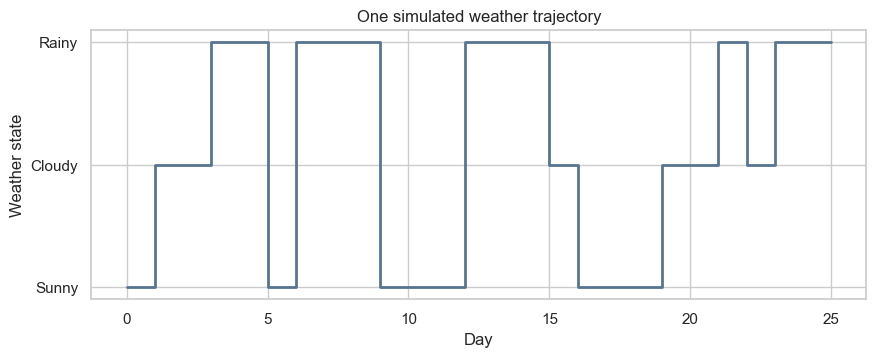

In [14]:
days = np.arange(len(trajectory))
state_codes = [state_to_idx[state] for state in trajectory]

plt.figure(figsize=(10, 3.5))
plt.step(days, state_codes, where="post", linewidth=2, color="#577590")
plt.yticks(list(state_to_idx.values()), list(state_to_idx.keys()))
plt.xlabel("Day")
plt.ylabel("Weather state")
plt.title("One simulated weather trajectory")
plt.show()


One sample path is useful for intuition, but a single run is noisy.
To estimate transition behavior accurately, we usually simulate many runs or use matrix algebra directly.


> 🤔 **THINKING**
>
> - If today is `Sunny`, do you expect `Sunny` or `Cloudy` to be more likely after 2 days?
> - Which state feels most "sticky" in this transition matrix?


### 2.3 Multi-step transitions

For Markov chains, multi-step probabilities come from matrix powers:

$$
P^n[i, j] = P( X_{t+n} = j \mid X_t = i )
$$

So the two-step and five-step behavior are already hidden inside repeated matrix multiplication.


In [15]:
def n_step_distribution(initial_distribution, P, n_steps):
    return initial_distribution @ np.linalg.matrix_power(P, n_steps)


P2 = np.linalg.matrix_power(P, 2)
P5 = np.linalg.matrix_power(P, 5)

print("Two-step transition matrix:")
display(pd.DataFrame(P2, index=states, columns=states).round(3))
print("Five-step transition matrix:")
display(pd.DataFrame(P5, index=states, columns=states).round(3))


Two-step transition matrix:


,Sunny,Cloudy,Rainy
Sunny,0.57,0.25,0.18
Cloudy,0.39,0.31,0.30
Rainy,0.33,0.31,0.36


Five-step transition matrix:


,Sunny,Cloudy,Rainy
Sunny,0.468,0.279,0.252
Cloudy,0.450,0.284,0.266
Rainy,0.443,0.286,0.271


In [16]:
initial_sunny = np.array([1.0, 0.0, 0.0])
print("Distribution after 1 day from Sunny:", n_step_distribution(initial_sunny, P, 1).round(3))
print("Distribution after 2 days from Sunny:", n_step_distribution(initial_sunny, P, 2).round(3))
print("Distribution after 5 days from Sunny:", n_step_distribution(initial_sunny, P, 5).round(3))


Distribution after 1 day from Sunny: [0.7 0.2 0.1]
Distribution after 2 days from Sunny: [0.57 0.25 0.18]
Distribution after 5 days from Sunny: [0.468 0.279 0.252]


In [17]:
def estimate_n_step_distribution(P, states, start_state, n_steps, n_trials=50_000, rng=None):
    rng = np.random.default_rng(rng)
    counts = np.zeros(len(states))
    start_idx = states.index(start_state)

    for _ in range(n_trials):
        current = start_idx
        for _ in range(n_steps):
            current = rng.choice(len(states), p=P[current])
        counts[current] += 1

    return counts / n_trials


estimated_2 = estimate_n_step_distribution(P, states, "Sunny", 2, rng=42)
exact_2 = n_step_distribution(initial_sunny, P, 2)

estimated_5 = estimate_n_step_distribution(P, states, "Sunny", 5, rng=123)
exact_5 = n_step_distribution(initial_sunny, P, 5)

multi_step_df = pd.DataFrame(
    {
        "Exact 2-step": exact_2,
        "MonteCarlo 2-step": estimated_2,
        "Exact 5-step": exact_5,
        "MonteCarlo 5-step": estimated_5,
    },
    index=states,
)
multi_step_df.round(4)


,Exact 2-step,MonteCarlo 2-step,Exact 5-step,MonteCarlo 5-step
Sunny,0.57,0.5699,0.4685,0.4700
Cloudy,0.25,0.2486,0.2794,0.2774
Rainy,0.18,0.1815,0.2521,0.2527


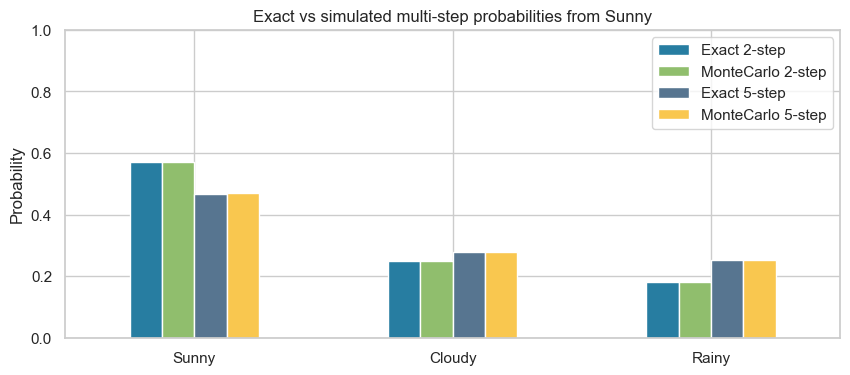

In [18]:
assert np.allclose(exact_2, estimated_2, atol=0.02)
assert np.allclose(exact_5, estimated_5, atol=0.02)

multi_step_df.plot(kind="bar", figsize=(10, 4), color=["#277da1", "#90be6d", "#577590", "#f9c74f"])
plt.title("Exact vs simulated multi-step probabilities from Sunny")
plt.ylabel("Probability")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.show()


### 2.4 Stationary distribution intuition

Some Markov chains settle into a stable long-run behavior.
A **stationary distribution** $\pi$ satisfies:

$$
\pi P = \pi
$$

Intuitively, if the chain starts in that distribution, one more step leaves the distribution unchanged.
Our weather matrix has all positive transition probabilities, so it is a friendly case that converges toward one long-run distribution from any starting point. Not every Markov chain does this; periodic or disconnected chains need more care.


In [19]:
initial_distributions = {
    "Start Sunny": np.array([1.0, 0.0, 0.0]),
    "Start Cloudy": np.array([0.0, 1.0, 0.0]),
    "Start Rainy": np.array([0.0, 0.0, 1.0]),
    "Uniform start": np.array([1 / 3, 1 / 3, 1 / 3]),
}

history = []
for label, dist in initial_distributions.items():
    current = dist.copy()
    for step in range(16):
        history.append(
            {
                "Start": label,
                "Step": step,
                "Sunny": current[0],
                "Cloudy": current[1],
                "Rainy": current[2],
            }
        )
        current = current @ P

history_df = pd.DataFrame(history)
history_df.head()


,Start,Step,Sunny,Cloudy,Rainy
0,Start Sunny,0,1.0000,0.0000,0.0000
1,Start Sunny,1,0.7000,0.2000,0.1000
2,Start Sunny,2,0.5700,0.2500,0.1800
3,Start Sunny,3,0.5100,0.2680,0.2220
4,Start Sunny,4,0.4818,0.2758,0.2424


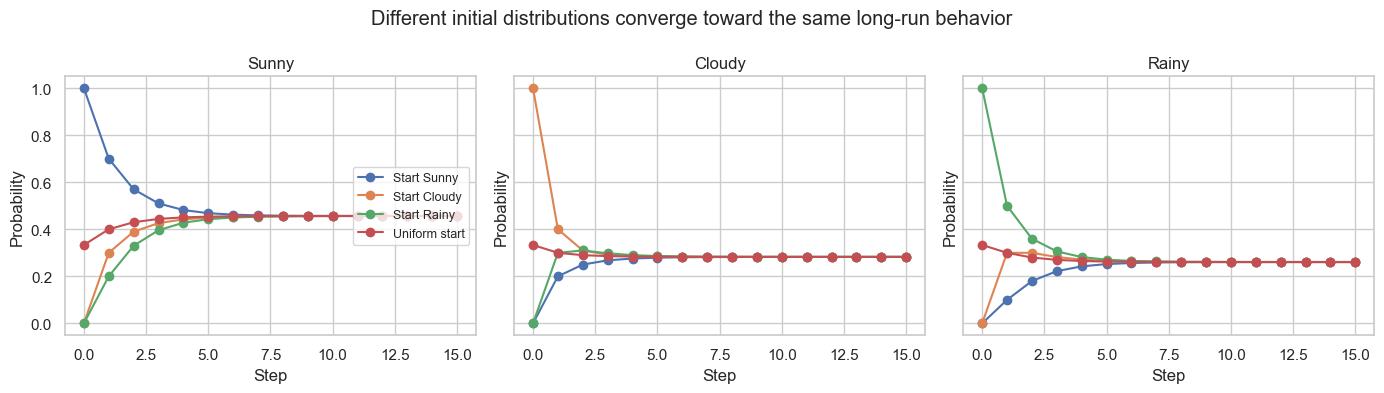

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True, sharey=True)
for ax, state in zip(axes, states, strict=False):
    for label in initial_distributions:
        subset = history_df[history_df["Start"] == label]
        ax.plot(subset["Step"], subset[state], marker="o", label=label)
    ax.set_title(state)
    ax.set_xlabel("Step")
    ax.set_ylabel("Probability")

axes[0].legend(loc="center right", fontsize=9)
fig.suptitle("Different initial distributions converge toward the same long-run behavior")
plt.tight_layout()
plt.show()


In [21]:
eigvals, eigvecs = np.linalg.eig(P.T)
stationary_vector = np.real(eigvecs[:, np.isclose(eigvals, 1.0)][:, 0])
stationary_distribution = stationary_vector / stationary_vector.sum()
stationary_distribution = stationary_distribution.real
stationary_distribution


array([0.45652174, 0.2826087 , 0.26086957])

In [22]:
stationary_df = pd.Series(stationary_distribution, index=states, name="Stationary")
print(stationary_df.round(4))
print("Check pi P:", (stationary_distribution @ P).round(4))
assert np.allclose(stationary_distribution @ P, stationary_distribution)


Sunny     0.4565
Cloudy    0.2826
Rainy     0.2609
Name: Stationary, dtype: float64
Check pi P: [0.4565 0.2826 0.2609]


In [23]:
long_trajectory = simulate_markov_chain(P, states, start_state="Sunny", n_steps=100_000, rng=7)
long_run_freq = pd.Series(long_trajectory[1:]).value_counts(normalize=True).reindex(states)

long_run_comparison = pd.DataFrame(
    {
        "Stationary": stationary_distribution,
        "Empirical long-run frequency": long_run_freq.values,
    },
    index=states,
)
long_run_comparison["AbsoluteError"] = (
    long_run_comparison["Stationary"] - long_run_comparison["Empirical long-run frequency"]
).abs()
long_run_comparison.round(4)


,Stationary,Empirical long-run frequency,AbsoluteError
Sunny,0.4565,0.4559,0.0006
Cloudy,0.2826,0.2810,0.0016
Rainy,0.2609,0.2631,0.0022


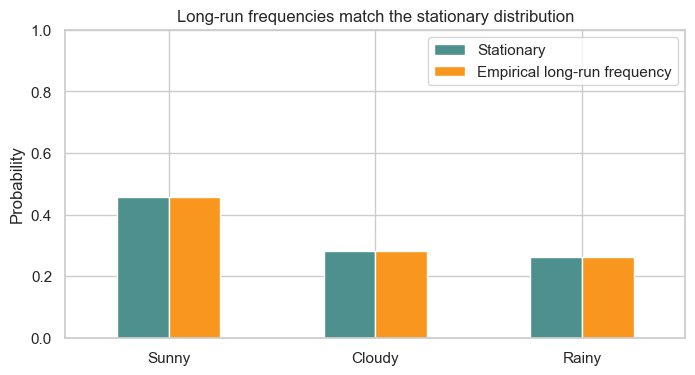

In [24]:
assert np.allclose(
    long_run_comparison["Stationary"],
    long_run_comparison["Empirical long-run frequency"],
    atol=0.02,
)

long_run_comparison[["Stationary", "Empirical long-run frequency"]].plot(
    kind="bar", figsize=(8, 4), color=["#4d908e", "#f8961e"]
)
plt.title("Long-run frequencies match the stationary distribution")
plt.ylabel("Probability")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.show()


> 📚 **EXERCISE**
>
> - Edit one row of the weather transition matrix and see how the long-run behavior changes.
> - Make `Rainy -> Rainy` larger and reduce the other probabilities in that row. What happens to the stationary distribution?
> - Make `Sunny -> Cloudy` larger. Does the final long-run distribution become less sunny?


### 2.5 A small fun extension: page-navigation chain

Weather is intuitive, but Markov chains also appear in user behavior.
Imagine a tiny website with three pages:
- `Home`
- `Search`
- `Checkout`

A visitor tends to loop between `Home` and `Search`, while `Checkout` is stickier: once a visitor reaches it, they are relatively likely to stay there on the next click.


In [25]:
web_states = ["Home", "Search", "Checkout"]
P_web = np.array(
    [
        [0.25, 0.65, 0.10],
        [0.35, 0.45, 0.20],
        [0.15, 0.15, 0.70],
    ]
)

web_df = pd.DataFrame(P_web, index=web_states, columns=web_states)
web_df


,Home,Search,Checkout
Home,0.25,0.65,0.1
Search,0.35,0.45,0.2
Checkout,0.15,0.15,0.7


In [26]:
initial_home = np.array([1.0, 0.0, 0.0])
for n in [1, 3, 8]:
    dist = n_step_distribution(initial_home, P_web, n)
    print(f"After {n} clicks from Home: {dict(zip(web_states, dist.round(3), strict=False))}")


After 1 clicks from Home: {'Home': np.float64(0.25), 'Search': np.float64(0.65), 'Checkout': np.float64(0.1)}
After 3 clicks from Home: {'Home': np.float64(0.274), 'Search': np.float64(0.444), 'Checkout': np.float64(0.282)}
After 8 clicks from Home: {'Home': np.float64(0.256), 'Search': np.float64(0.398), 'Checkout': np.float64(0.346)}


This kind of model is a useful mental bridge toward recommendation systems, click modeling, and ranking algorithms.
The same transition-matrix ideas keep reappearing in larger systems.


## Wrap-up

We used two different views of uncertainty:
- **Bayesian network**: a graph of dependencies among variables
- **Markov chain**: a chain of state transitions over time

Both models are simple enough to implement from scratch, yet powerful enough to support real reasoning.


As you move forward, you can think of several richer successors:
- Hidden Markov Models add unobserved latent states
- RNNs learn sequence dynamics from data instead of fixed transition tables
- Transformers model long-range interactions far beyond one-step Markov assumptions
